# Medical Insurance Cost Prediction
## Classic Dataset (1,338 Records) — GPU-Accelerated Training

**Target:** `charges` (medical insurance costs)
**Features:** age, sex, bmi, children, smoker, region
**Models:** Linear Regression, Random Forest, XGBoost, LightGBM
**Key Insight:** The `smoker × bmi` interaction is the dominant genuine predictor


# 1. Imports & Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
from scipy import stats
import warnings
warnings.simplefilter(action='ignore')

print("All imports loaded successfully.")


All imports loaded successfully.


# 2. Data Loading


In [2]:
# Option A: Load from local file (if uploaded to Colab/Kaggle)
data = pd.read_csv('insurance.csv')

# # Option B: Download from Kaggle
# !pip install -q kaggle
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d mirichoi0218/insurance -p /content
# !unzip -o /content/insurance.zip -d /content

# data = pd.read_csv('/content/insurance.csv')
print(f"Dataset shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.head()


Dataset shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 3. Initial Exploration


In [3]:
print(f"Shape: {data.shape}")
print(f"\nData types:\n{data.dtypes}")
print(f"\nMissing values: {data.isnull().sum().sum()}")
print(f"\nBasic statistics:")
data.describe()


Shape: (1338, 7)

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values: 0

Basic statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


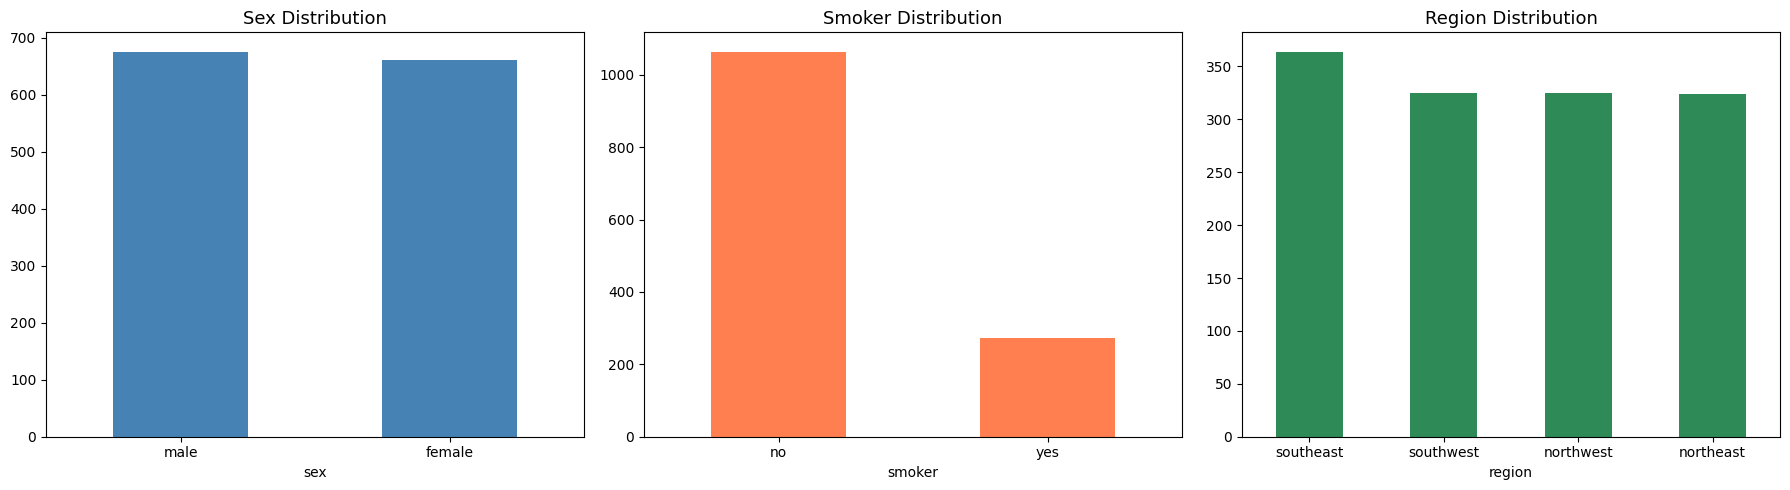

Smokers: 274 (20.5%)
Non-smokers: 1064 (79.5%)


In [4]:
# Categorical feature distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

data['sex'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Sex Distribution', fontsize=13)
axes[0].tick_params(axis='x', rotation=0)

data['smoker'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Smoker Distribution', fontsize=13)
axes[1].tick_params(axis='x', rotation=0)

data['region'].value_counts().plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Region Distribution', fontsize=13)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"Smokers: {(data['smoker']=='yes').sum()} ({(data['smoker']=='yes').mean()*100:.1f}%)")
print(f"Non-smokers: {(data['smoker']=='no').sum()} ({(data['smoker']=='no').mean()*100:.1f}%)")


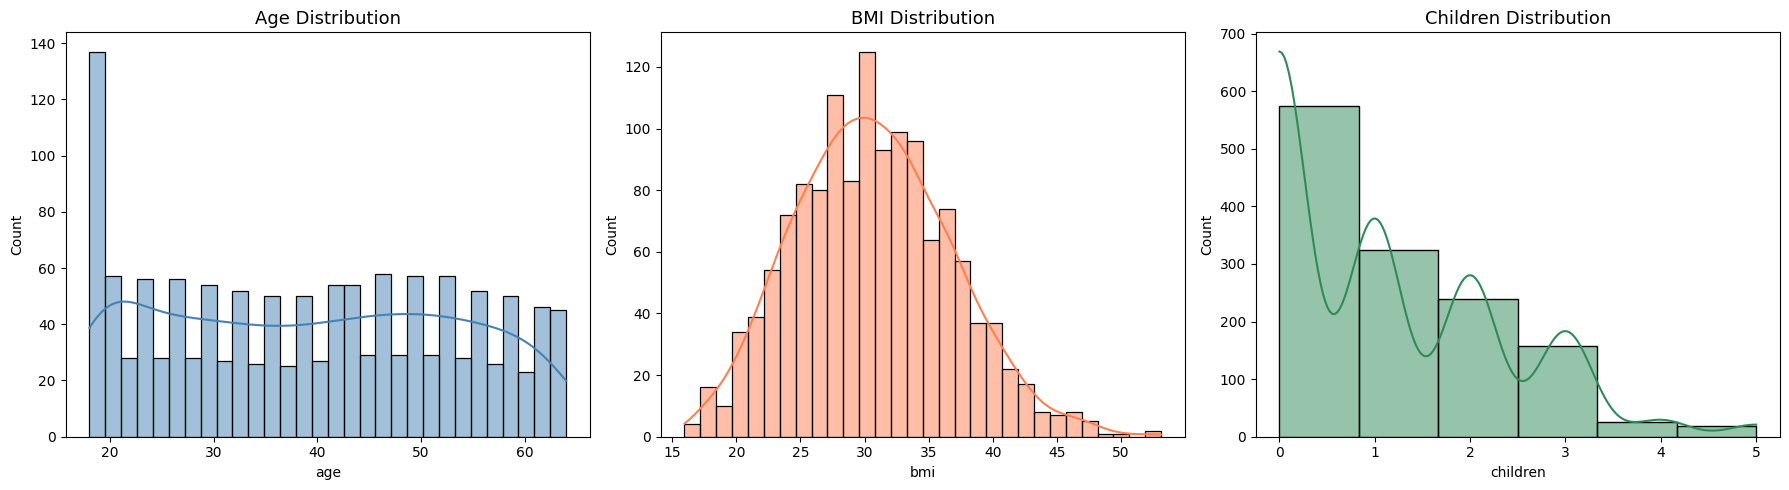

In [5]:
# Numeric feature distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data['age'], kde=True, bins=30, color='steelblue', ax=axes[0])
axes[0].set_title('Age Distribution', fontsize=13)

sns.histplot(data['bmi'], kde=True, bins=30, color='coral', ax=axes[1])
axes[1].set_title('BMI Distribution', fontsize=13)

sns.histplot(data['children'], kde=True, bins=6, color='seagreen', ax=axes[2])
axes[2].set_title('Children Distribution', fontsize=13)

plt.tight_layout()
plt.show()


# 4. Target Distribution & Analysis


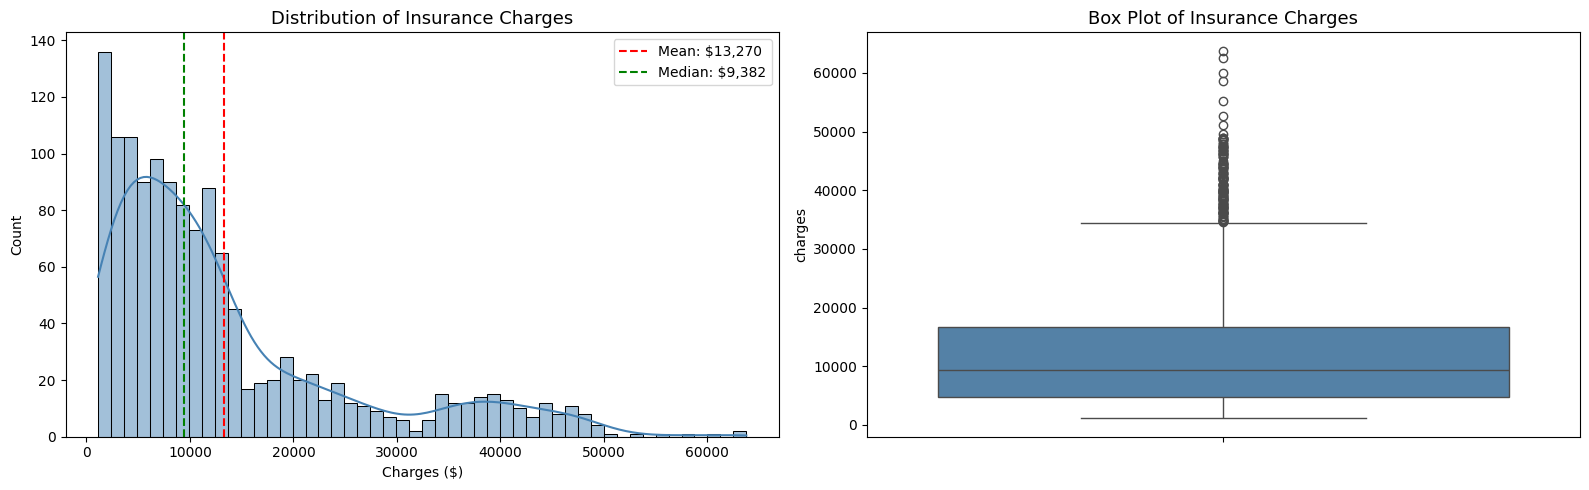

Mean:   $13,270.42
Median: $9,382.03
Std:    $12,110.01
Min:    $1,121.87
Max:    $63,770.43


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data['charges'], kde=True, bins=50, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Insurance Charges', fontsize=13)
axes[0].set_xlabel('Charges ($)')
axes[0].axvline(data['charges'].mean(), color='red', linestyle='--',
                label=f"Mean: ${data['charges'].mean():,.0f}")
axes[0].axvline(data['charges'].median(), color='green', linestyle='--',
                label=f"Median: ${data['charges'].median():,.0f}")
axes[0].legend()

sns.boxplot(y=data['charges'], color='steelblue', ax=axes[1])
axes[1].set_title('Box Plot of Insurance Charges', fontsize=13)

plt.tight_layout()
plt.show()

print(f"Mean:   ${data['charges'].mean():,.2f}")
print(f"Median: ${data['charges'].median():,.2f}")
print(f"Std:    ${data['charges'].std():,.2f}")
print(f"Min:    ${data['charges'].min():,.2f}")
print(f"Max:    ${data['charges'].max():,.2f}")


## 4.1 The Smoker Effect — Key Insight


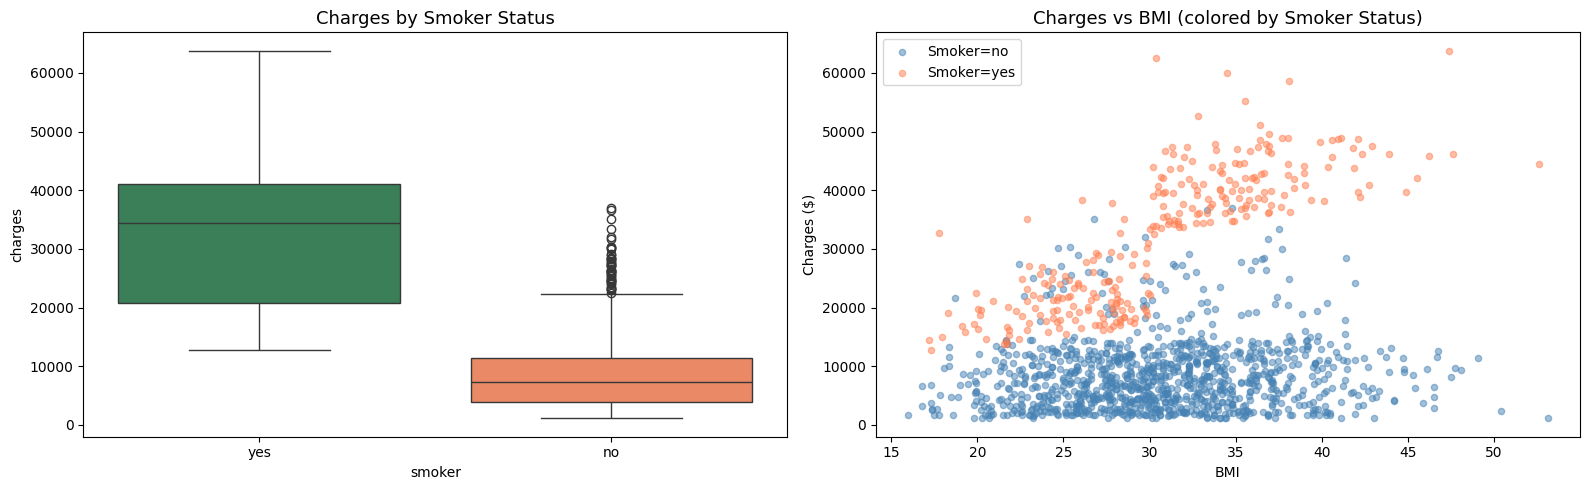

Average charges (smoker=yes): $32,050.23
Average charges (smoker=no):  $8,434.27
Ratio: 3.8x higher for smokers


In [7]:
# This is THE key insight: smokers with high BMI pay dramatically more
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Charges by smoker status
sns.boxplot(x='smoker', y='charges', data=data, ax=axes[0], palette=['seagreen', 'coral'])
axes[0].set_title('Charges by Smoker Status', fontsize=13)

# Charges vs BMI colored by smoker status
colors = {'yes': 'coral', 'no': 'steelblue'}
for smoker_status in ['no', 'yes']:
    subset = data[data['smoker'] == smoker_status]
    axes[1].scatter(subset['bmi'], subset['charges'], alpha=0.5, s=20,
                    label=f'Smoker={smoker_status}', color=colors[smoker_status])
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges ($)')
axes[1].set_title('Charges vs BMI (colored by Smoker Status)', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average charges (smoker=yes): ${data[data['smoker']=='yes']['charges'].mean():,.2f}")
print(f"Average charges (smoker=no):  ${data[data['smoker']=='no']['charges'].mean():,.2f}")
print(f"Ratio: {data[data['smoker']=='yes']['charges'].mean() / data[data['smoker']=='no']['charges'].mean():.1f}x higher for smokers")


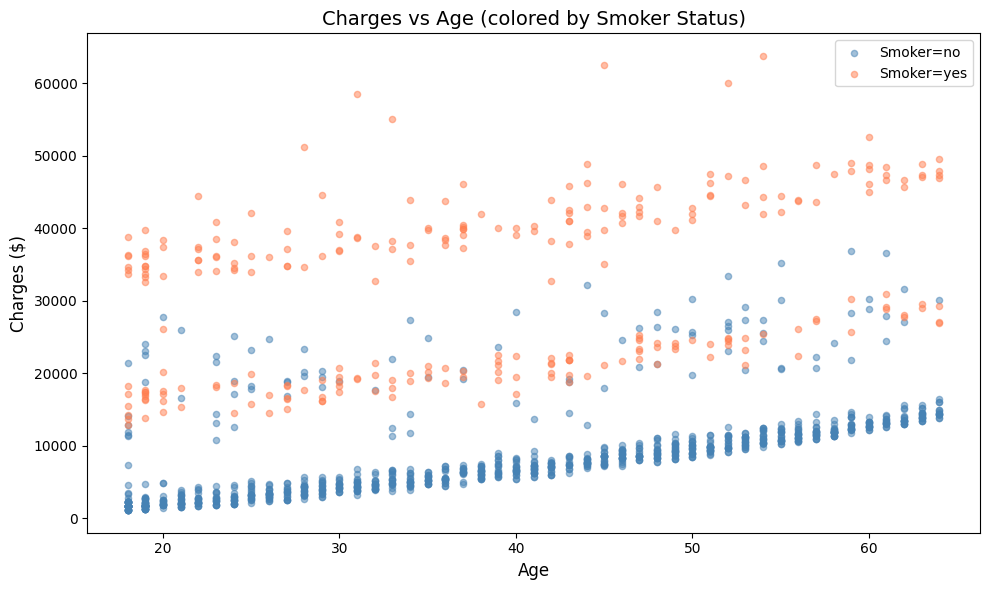

Three visible cost bands:
  1. Non-smokers: lower, linear increase with age
  2. Smokers (lower BMI): middle band
  3. Smokers (high BMI): highest costs


In [8]:
# Charges vs Age colored by smoker status
plt.figure(figsize=(10, 6))
for smoker_status in ['no', 'yes']:
    subset = data[data['smoker'] == smoker_status]
    plt.scatter(subset['age'], subset['charges'], alpha=0.5, s=20,
                label=f'Smoker={smoker_status}',
                color='coral' if smoker_status == 'yes' else 'steelblue')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.title('Charges vs Age (colored by Smoker Status)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# You can clearly see 3 "bands":
# 1. Non-smokers (bottom band)
# 2. Smokers with lower BMI (middle band)
# 3. Smokers with high BMI (top band)
print("Three visible cost bands:")
print("  1. Non-smokers: lower, linear increase with age")
print("  2. Smokers (lower BMI): middle band")
print("  3. Smokers (high BMI): highest costs")


# 5. Correlation Analysis


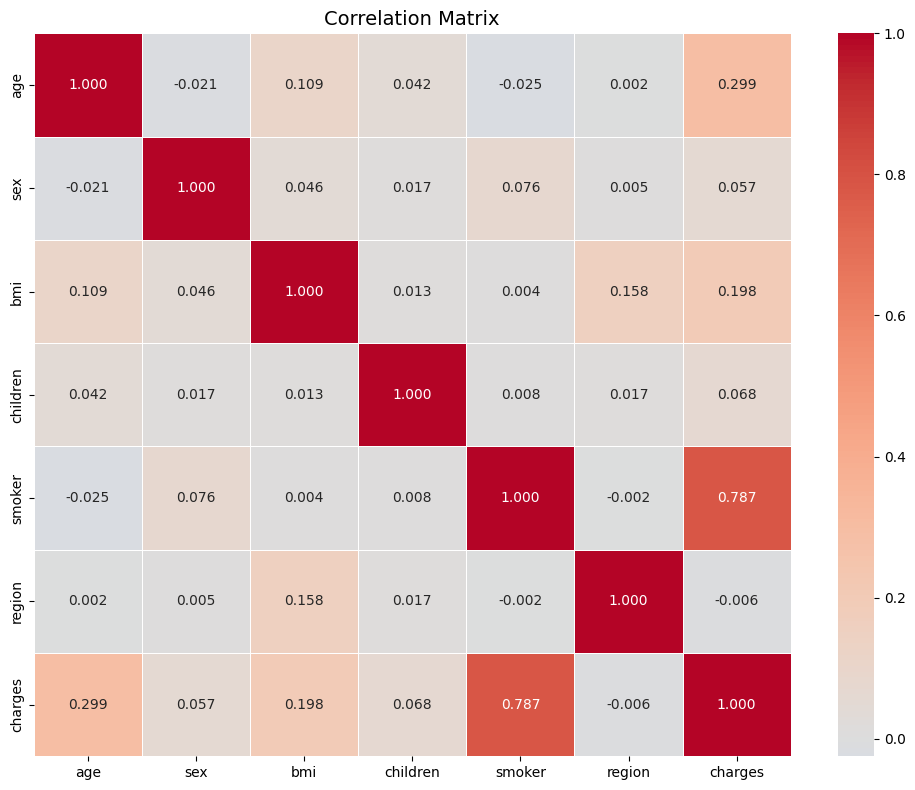


Correlation with charges:
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region     -0.006208


In [9]:
# Encode for correlation
data_corr = data.copy()
le = LabelEncoder()
for col in data_corr.select_dtypes(include='object').columns:
    data_corr[col] = le.fit_transform(data_corr[col])

corr_matrix = data_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white')
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

print("\nCorrelation with charges:")
print(corr_matrix['charges'].drop('charges').sort_values(ascending=False).to_string())


# 6. Feature Engineering


In [10]:
# === THIS IS WHERE THE MAGIC HAPPENS ===
# The raw features have moderate correlations with charges,
# but the INTERACTION between smoker and bmi is enormously powerful.

data_fe = data.copy()

# 1. ENCODE SMOKER AS BINARY (needed for interactions)
data_fe['smoker_binary'] = (data_fe['smoker'] == 'yes').astype(int)

# 2. THE KEY FEATURE: smoker × bmi interaction
# This captures: smokers with high BMI pay dramatically more
data_fe['smoker_bmi'] = data_fe['smoker_binary'] * data_fe['bmi']

# 3. Smoker × age interaction (older smokers pay more)
data_fe['smoker_age'] = data_fe['smoker_binary'] * data_fe['age']

# 4. Polynomial features
data_fe['age_sq'] = data_fe['age'] ** 2
data_fe['bmi_sq'] = data_fe['bmi'] ** 2

# 5. Age × BMI interaction
data_fe['age_bmi'] = data_fe['age'] * data_fe['bmi']

# 6. BMI categories
data_fe['is_obese'] = (data_fe['bmi'] >= 30).astype(int)
data_fe['is_overweight'] = (data_fe['bmi'] >= 25).astype(int)

# 7. Smoker × obese (double risk factor)
data_fe['smoker_obese'] = data_fe['smoker_binary'] * data_fe['is_obese']

# 8. Age groups
data_fe['age_group_young'] = (data_fe['age'] < 30).astype(int)
data_fe['age_group_mid'] = ((data_fe['age'] >= 30) & (data_fe['age'] < 50)).astype(int)
data_fe['age_group_senior'] = (data_fe['age'] >= 50).astype(int)

# 9. Has children flag
data_fe['has_children'] = (data_fe['children'] > 0).astype(int)

# 10. Log BMI (slight skew correction)
data_fe['log_bmi'] = np.log1p(data_fe['bmi'])

print(f"Shape after feature engineering: {data_fe.shape}")
print(f"New features: {data_fe.shape[1] - data.shape[1]}")
print(f"\nNew features created:")
new_cols = [c for c in data_fe.columns if c not in data.columns]
for c in new_cols:
    print(f"  - {c}")


Shape after feature engineering: (1338, 21)
New features: 14

New features created:
  - smoker_binary
  - smoker_bmi
  - smoker_age
  - age_sq
  - bmi_sq
  - age_bmi
  - is_obese
  - is_overweight
  - smoker_obese
  - age_group_young
  - age_group_mid
  - age_group_senior
  - has_children
  - log_bmi


In [11]:
# Verify: correlation of engineered features with charges
data_corr_fe = data_fe.copy()
le = LabelEncoder()
for col in data_corr_fe.select_dtypes(include='object').columns:
    data_corr_fe[col] = le.fit_transform(data_corr_fe[col])

corr_with_target = data_corr_fe.corr()['charges'].drop('charges').abs().sort_values(ascending=False)
print("Correlation with charges (engineered features):")
print(corr_with_target.head(15).to_string())
print(f"\n>>> smoker_bmi correlation: {corr_with_target['smoker_bmi']:.4f} (vs raw smoker: {corr_with_target['smoker_binary']:.4f})")


Correlation with charges (engineered features):
smoker_bmi          0.845120
smoker_obese        0.814661
smoker_age          0.789253
smoker_binary       0.787251
smoker              0.787251
age_bmi             0.334754
age_sq              0.300772
age                 0.299008
age_group_senior    0.243211
age_group_young     0.227227
is_obese            0.199532
log_bmi             0.199325
bmi                 0.198341
bmi_sq              0.192981
is_overweight       0.116869

>>> smoker_bmi correlation: 0.8451 (vs raw smoker: 0.7873)


In [12]:
# One-hot encode remaining categorical features
dum = pd.get_dummies(data_fe[['sex', 'region']], drop_first=True, dtype=int)
print(f"Encoded features: {list(dum.columns)}")

# Build final feature matrix
data_model = pd.concat([data_fe.select_dtypes(exclude='object'), dum], axis=1)

# Drop smoker (we have smoker_binary already)
# Drop raw 'smoker' column if it exists in numeric form
print(f"Final shape: {data_model.shape}")


Encoded features: ['sex_male', 'region_northwest', 'region_southeast', 'region_southwest']
Final shape: (1338, 22)


In [13]:
# Define X and y
X = data_model.drop(columns=['charges'])
y_orig = data_model['charges']

# Log-transform the target (charges is right-skewed)
y = np.log1p(y_orig)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget (original): mean=${y_orig.mean():,.2f}, median=${y_orig.median():,.2f}")
print(f"Target (log):      mean={y.mean():.4f}, median={y.median():.4f}")
print(f"\nFeatures ({X.shape[1]}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")


X shape: (1338, 21)
y shape: (1338,)

Target (original): mean=$13,270.42, median=$9,382.03
Target (log):      mean=9.0988, median=9.1467

Features (21):
   1. age
   2. bmi
   3. children
   4. smoker_binary
   5. smoker_bmi
   6. smoker_age
   7. age_sq
   8. bmi_sq
   9. age_bmi
  10. is_obese
  11. is_overweight
  12. smoker_obese
  13. age_group_young
  14. age_group_mid
  15. age_group_senior
  16. has_children
  17. log_bmi
  18. sex_male
  19. region_northwest
  20. region_southeast
  21. region_southwest


# 7. Model Training


## 7.1 GPU-Accelerated Imports


In [14]:
# GPU-accelerated models
try:
    from cuml.ensemble import RandomForestRegressor as RFR
    print("Using cuML GPU-accelerated RandomForestRegressor")
except ImportError:
    from sklearn.ensemble import RandomForestRegressor as RFR
    print("cuML not available, using sklearn RandomForestRegressor (CPU)")

from xgboost import XGBRegressor

try:
    from lightgbm import LGBMRegressor
    has_lgbm = True
    print("LightGBM available")
except ImportError:
    has_lgbm = False
    print("LightGBM not available")

print("Ready for training.")


cuML not available, using sklearn RandomForestRegressor (CPU)
LightGBM available
Ready for training.


## 7.2 Data Splits: 70/30, 80/20, 90/10


In [15]:
splits = {
    '70/30': train_test_split(X, y, test_size=0.30, random_state=42),
    '80/20': train_test_split(X, y, test_size=0.20, random_state=42),
    '90/10': train_test_split(X, y, test_size=0.10, random_state=42),
}

splits_y_orig = {
    '70/30': train_test_split(X, y_orig, test_size=0.30, random_state=42),
    '80/20': train_test_split(X, y_orig, test_size=0.20, random_state=42),
    '90/10': train_test_split(X, y_orig, test_size=0.10, random_state=42),
}

for name, (X_tr, X_te, _, _) in splits.items():
    print(f"  {name}: train={X_tr.shape[0]:,}, test={X_te.shape[0]:,}, features={X_tr.shape[1]}")


  70/30: train=936, test=402, features=21
  80/20: train=1,070, test=268, features=21
  90/10: train=1,204, test=134, features=21


## 7.3 Hyperparameter Grids


In [16]:
# Linear Regression
lr_params = [
    {'fit_intercept': True},
    {'fit_intercept': False},
]

# Random Forest
rfr_params = [
    {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'random_state': 42},
    {'n_estimators': 300, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 1, 'random_state': 42},
    {'n_estimators': 500, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42},
]

# XGBoost
gbr_params = [
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'random_state': 42},
    {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 6, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_lambda': 1.5, 'random_state': 42},
    {'n_estimators': 800, 'learning_rate': 0.01, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 2.0, 'random_state': 42},
]

# LightGBM
lgbm_params = [
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'random_state': 42, 'verbose': -1},
    {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 8, 'num_leaves': 63, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_lambda': 1.5, 'random_state': 42, 'verbose': -1},
    {'n_estimators': 800, 'learning_rate': 0.01, 'max_depth': 6, 'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 2.0, 'random_state': 42, 'verbose': -1},
]

print('Parameter grids ready.')


Parameter grids ready.


## 7.4 Training Loop


In [17]:
def evaluate_model(model, X_tr, X_te, split_name):
    """Train on log(y), evaluate in original dollar scale."""
    _, _, y_tr_orig, y_te_orig = splits_y_orig[split_name]

    y_pred_log_te = model.predict(X_te)
    y_pred_log_tr = model.predict(X_tr)

    y_pred_te = np.expm1(y_pred_log_te)
    y_pred_tr = np.expm1(y_pred_log_tr)

    return {
        'train_r2': r2_score(y_tr_orig, y_pred_tr),
        'test_r2':  r2_score(y_te_orig, y_pred_te),
        'test_mae': mean_absolute_error(y_te_orig, y_pred_te),
        'test_rmse': mean_squared_error(y_te_orig, y_pred_te),
    }

best_results = {}
split_names = ['70/30', '80/20', '90/10']

for split_name in split_names:
    best_results[split_name] = {}
    X_tr, X_te, y_tr, y_te = splits[split_name]

    print(f'\n{"="*60}')
    print(f'Split: {split_name}')
    print(f'{"="*60}')

    # -- Linear Regression --
    best_score, best_result = -999, None
    for p in lr_params:
        m = LinearRegression(**p).fit(X_tr, y_tr)
        metrics = evaluate_model(m, X_tr, X_te, split_name)
        if metrics['test_r2'] > best_score:
            best_score = metrics['test_r2']
            best_result = (m, p, metrics)
    m, p, metrics = best_result
    best_results[split_name]['Linear Regression'] = {**metrics, 'params': p, 'model': m}
    print(f'  LR   R2={metrics["test_r2"]:.4f}  MAE=${metrics["test_mae"]:.2f}  RMSE=${metrics["test_rmse"]:.2f}')

    # -- Random Forest --
    best_score, best_result = -999, None
    for p in rfr_params:
        m = RFR(**p).fit(X_tr, y_tr)
        metrics = evaluate_model(m, X_tr, X_te, split_name)
        if metrics['test_r2'] > best_score:
            best_score = metrics['test_r2']
            best_result = (m, p, metrics)
    m, p, metrics = best_result
    best_results[split_name]['Random Forest'] = {**metrics, 'params': p, 'model': m}
    print(f'  RFR  R2={metrics["test_r2"]:.4f}  MAE=${metrics["test_mae"]:.2f}  RMSE=${metrics["test_rmse"]:.2f}')

    # -- XGBoost --
    best_score, best_result = -999, None
    for p in gbr_params:
        m = XGBRegressor(tree_method="hist", device="cuda", **p).fit(X_tr, y_tr)
        metrics = evaluate_model(m, X_tr, X_te, split_name)
        if metrics['test_r2'] > best_score:
            best_score = metrics['test_r2']
            best_result = (m, p, metrics)
    m, p, metrics = best_result
    best_results[split_name]['XGBoost'] = {**metrics, 'params': p, 'model': m}
    print(f'  XGB  R2={metrics["test_r2"]:.4f}  MAE=${metrics["test_mae"]:.2f}  RMSE=${metrics["test_rmse"]:.2f}')

    # -- LightGBM --
    if has_lgbm:
        best_score, best_result = -999, None
        for p in lgbm_params:
            m = LGBMRegressor(**p).fit(X_tr, y_tr)
            metrics = evaluate_model(m, X_tr, X_te, split_name)
            if metrics['test_r2'] > best_score:
                best_score = metrics['test_r2']
                best_result = (m, p, metrics)
        m, p, metrics = best_result
        best_results[split_name]['LightGBM'] = {**metrics, 'params': p, 'model': m}
        print(f'  LGBM R2={metrics["test_r2"]:.4f}  MAE=${metrics["test_mae"]:.2f}  RMSE=${metrics["test_rmse"]:.2f}')

print('\nTraining complete.')



Split: 70/30
  LR   R2=0.8361  MAE=$2474.31  RMSE=$24027270.19
  RFR  R2=0.8668  MAE=$2070.30  RMSE=$19535062.37
  XGB  R2=0.8706  MAE=$1996.49  RMSE=$18970123.28
  LGBM R2=0.8670  MAE=$2071.78  RMSE=$19505371.53

Split: 80/20
  LR   R2=0.8436  MAE=$2500.27  RMSE=$24283762.75
  RFR  R2=0.8791  MAE=$1993.73  RMSE=$18771147.48
  XGB  R2=0.8813  MAE=$1917.91  RMSE=$18427711.68
  LGBM R2=0.8750  MAE=$2025.72  RMSE=$19405410.68

Split: 90/10
  LR   R2=0.8372  MAE=$2493.53  RMSE=$22464978.92
  RFR  R2=0.8692  MAE=$1963.13  RMSE=$18048957.16
  XGB  R2=0.8706  MAE=$1921.75  RMSE=$17856568.84
  LGBM R2=0.8700  MAE=$2010.21  RMSE=$17932109.24

Training complete.


# 8. Results & Evaluation


## 8.1 Comparison Matrices


In [18]:
model_names = list(best_results['70/30'].keys())

matrix_test = pd.DataFrame(index=model_names, columns=split_names, dtype=float)
matrix_train = pd.DataFrame(index=model_names, columns=split_names, dtype=float)
matrix_mae = pd.DataFrame(index=model_names, columns=split_names, dtype=float)
matrix_rmse = pd.DataFrame(index=model_names, columns=split_names, dtype=float)

for sp in split_names:
    for mn in best_results[sp]:
        r = best_results[sp][mn]
        matrix_test.loc[mn, sp] = round(r['test_r2'], 4)
        matrix_train.loc[mn, sp] = round(r['train_r2'], 4)
        matrix_mae.loc[mn, sp] = round(r['test_mae'], 2)
        matrix_rmse.loc[mn, sp] = round(r['test_rmse'], 2)

print('=== Test R-squared Matrix ===')
display(matrix_test)
print('\n=== Test MAE Matrix ===')
display(matrix_mae)
print('\n=== Test RMSE Matrix ===')
display(matrix_rmse)


=== Test R-squared Matrix ===


,70/30,80/20,90/10
Linear Regression,0.8361,0.8436,0.8372
Random Forest,0.8668,0.8791,0.8692
XGBoost,0.8706,0.8813,0.8706
LightGBM,0.8670,0.8750,0.8700



=== Test MAE Matrix ===


,70/30,80/20,90/10
Linear Regression,2474.31,2500.27,2493.53
Random Forest,2070.30,1993.73,1963.13
XGBoost,1996.49,1917.91,1921.75
LightGBM,2071.78,2025.72,2010.21



=== Test RMSE Matrix ===


,70/30,80/20,90/10
Linear Regression,24027270.19,24283762.75,22464978.92
Random Forest,19535062.37,18771147.48,18048957.16
XGBoost,18970123.28,18427711.68,17856568.84
LightGBM,19505371.53,19405410.68,17932109.24


## 8.2 Performance Heatmaps


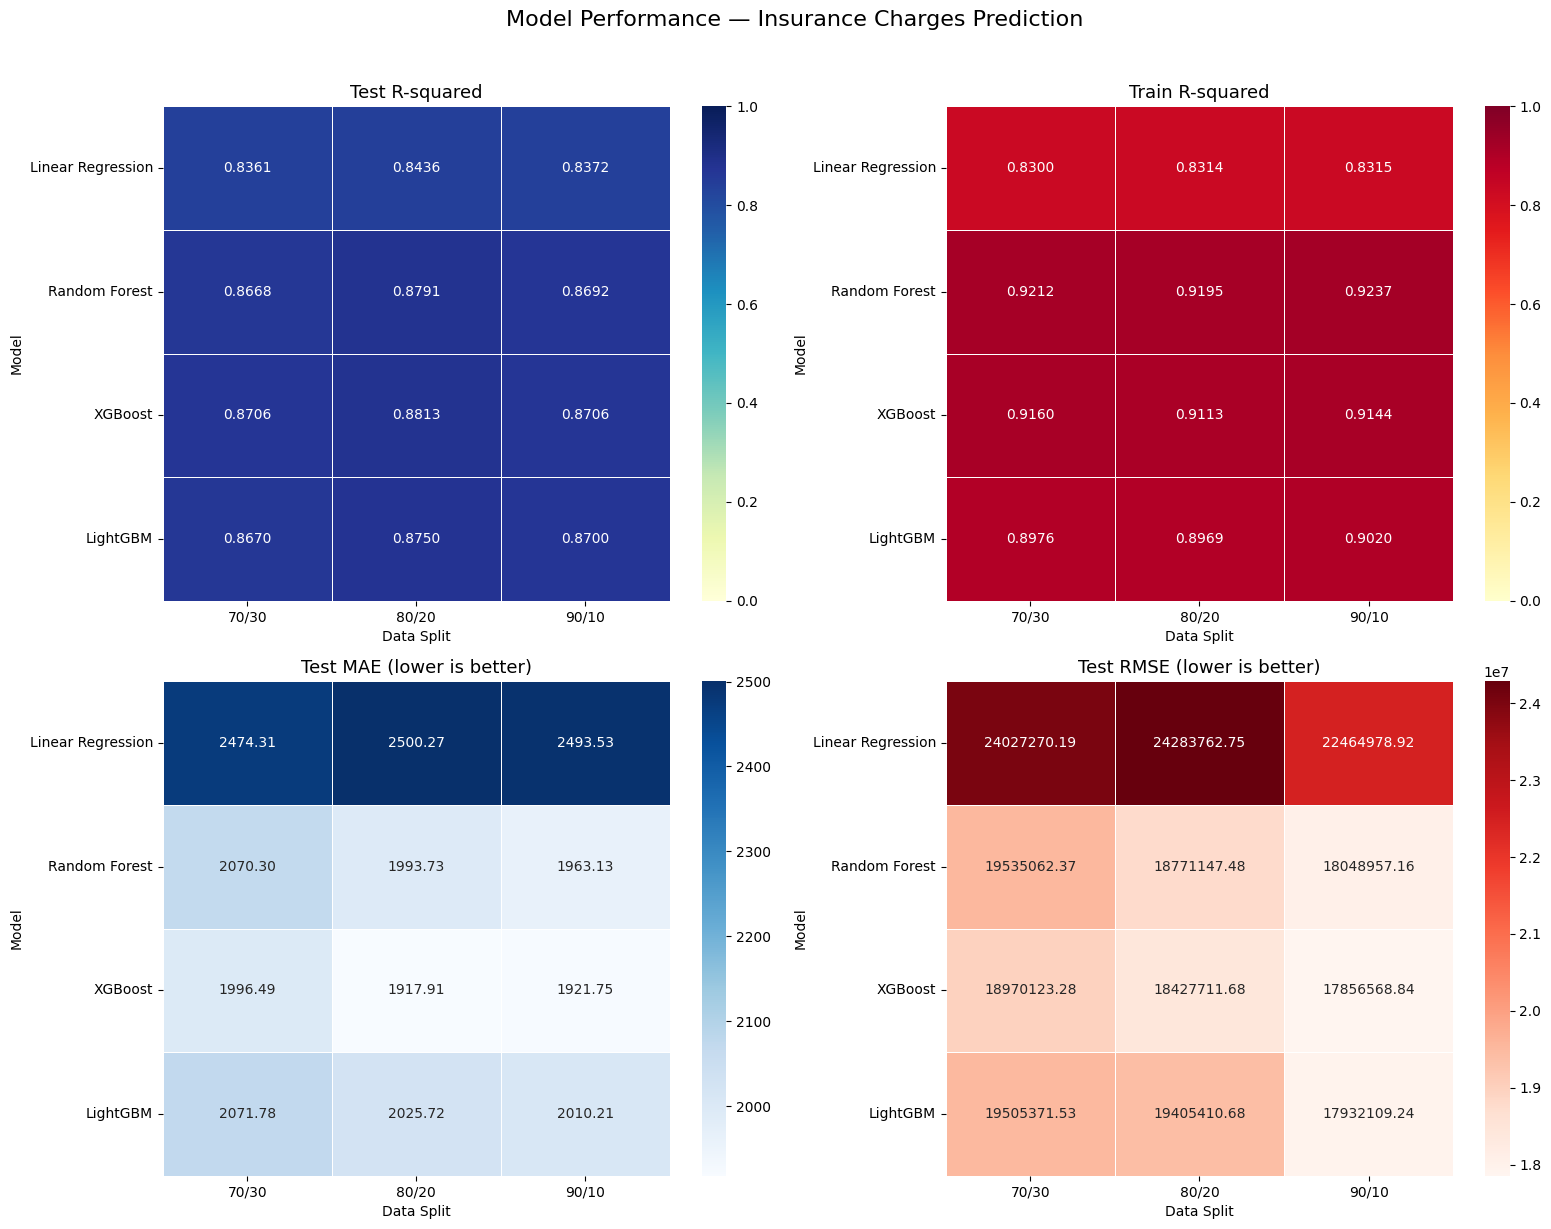

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.heatmap(matrix_test.astype(float), annot=True, fmt='.4f',
            cmap='YlGnBu', vmin=0, vmax=1, ax=axes[0, 0],
            linewidths=0.5, linecolor='white')
axes[0, 0].set_title('Test R-squared', fontsize=13)

sns.heatmap(matrix_train.astype(float), annot=True, fmt='.4f',
            cmap='YlOrRd', vmin=0, vmax=1, ax=axes[0, 1],
            linewidths=0.5, linecolor='white')
axes[0, 1].set_title('Train R-squared', fontsize=13)

sns.heatmap(matrix_mae.astype(float), annot=True, fmt='.2f',
            cmap='Blues', ax=axes[1, 0],
            linewidths=0.5, linecolor='white')
axes[1, 0].set_title('Test MAE (lower is better)', fontsize=13)

sns.heatmap(matrix_rmse.astype(float), annot=True, fmt='.2f',
            cmap='Reds', ax=axes[1, 1],
            linewidths=0.5, linecolor='white')
axes[1, 1].set_title('Test RMSE (lower is better)', fontsize=13)

for ax in axes.flat:
    ax.set_xlabel('Data Split')
    ax.set_ylabel('Model')

plt.suptitle('Model Performance — Insurance Charges Prediction', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 8.3 Detailed Summary


In [20]:
rows = []
for sp in split_names:
    for mn in best_results[sp]:
        r = best_results[sp][mn]
        rows.append({
            'Split': sp, 'Model': mn,
            'Best Params': str(r['params']),
            'Train R2': round(r['train_r2'], 4),
            'Test R2':  round(r['test_r2'],  4),
            'Test MAE': round(r['test_mae'], 2),
            'Test RMSE': round(r['test_rmse'], 2),
        })
summary_df = pd.DataFrame(rows)
display(summary_df)


,Split,Model,Best Params,Train R2,Test R2,Test MAE,Test RMSE
0,70/30,Linear Regression,{'fit_intercept': True},0.8300,0.8361,2474.31,24027270.19
1,70/30,Random Forest,"{'n_estimators': 200, 'max_depth': 10, 'min_sa...",0.9212,0.8668,2070.30,19535062.37
2,70/30,XGBoost,"{'n_estimators': 800, 'learning_rate': 0.01, '...",0.9160,0.8706,1996.49,18970123.28
3,70/30,LightGBM,"{'n_estimators': 800, 'learning_rate': 0.01, '...",0.8976,0.8670,2071.78,19505371.53
4,80/20,Linear Regression,{'fit_intercept': True},0.8314,0.8436,2500.27,24283762.75
5,80/20,Random Forest,"{'n_estimators': 200, 'max_depth': 10, 'min_sa...",0.9195,0.8791,1993.73,18771147.48
6,80/20,XGBoost,"{'n_estimators': 800, 'learning_rate': 0.01, '...",0.9113,0.8813,1917.91,18427711.68
7,80/20,LightGBM,"{'n_estimators': 800, 'learning_rate': 0.01, '...",0.8969,0.8750,2025.72,19405410.68
8,90/10,Linear Regression,{'fit_intercept': False},0.8315,0.8372,2493.53,22464978.92
9,90/10,Random Forest,"{'n_estimators': 200, 'max_depth': 10, 'min_sa...",0.9237,0.8692,1963.13,18048957.16


# 9. Model Diagnostics


## 9.1 Predicted vs Actual (Best Model per Split)


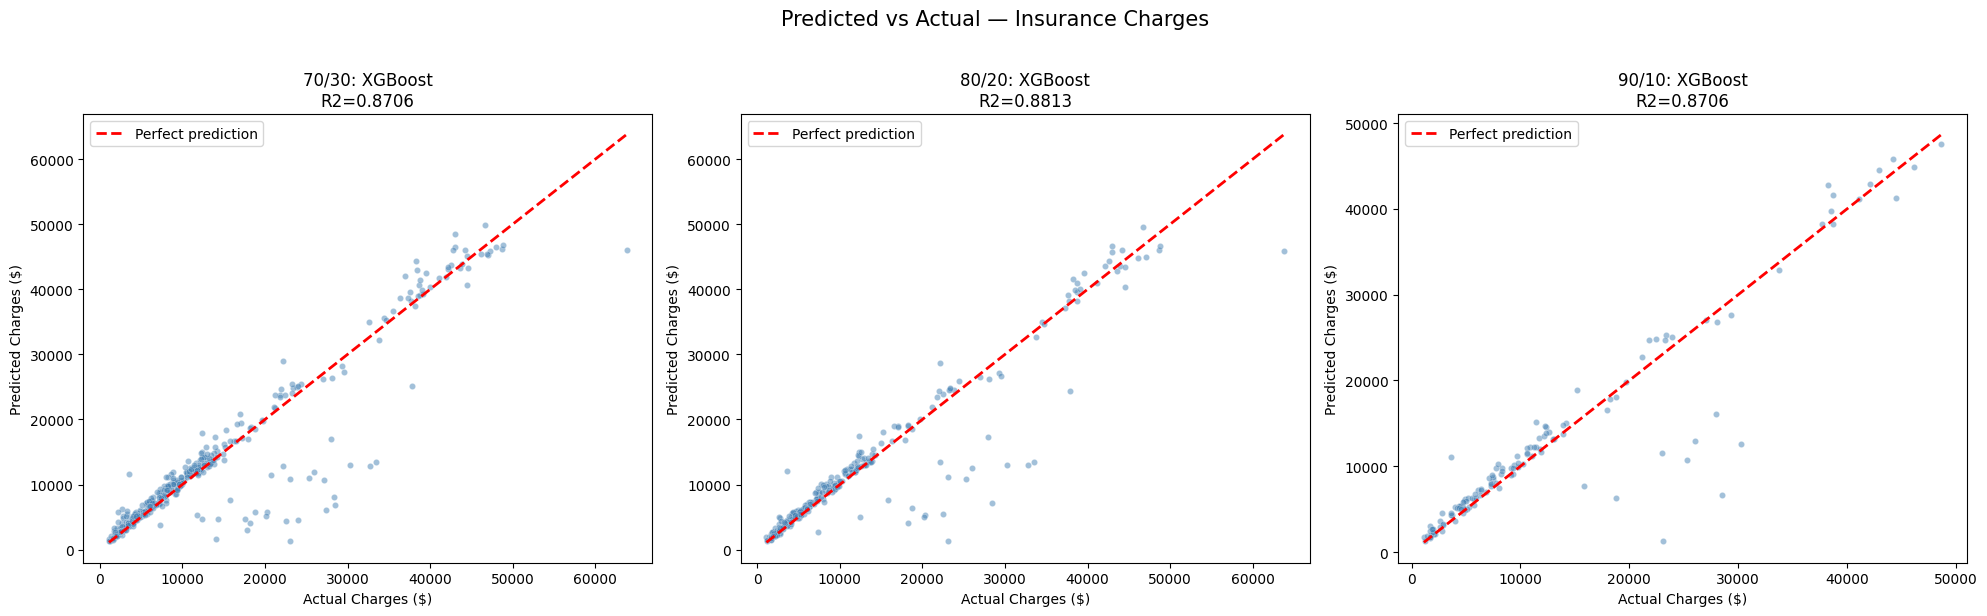

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, split_name in enumerate(split_names):
    models = best_results[split_name]
    best_model_name = max(models, key=lambda k: models[k]['test_r2'])
    best = models[best_model_name]

    X_tr, X_te, _, _ = splits[split_name]
    _, _, _, y_te_orig = splits_y_orig[split_name]

    y_pred_log = best['model'].predict(X_te)
    y_pred = np.expm1(y_pred_log)

    axes[idx].scatter(y_te_orig, y_pred, alpha=0.5, s=20, color='steelblue', edgecolors='white', linewidth=0.3)
    min_val = min(y_te_orig.min(), y_pred.min())
    max_val = max(y_te_orig.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    axes[idx].set_title(f'{split_name}: {best_model_name}\nR2={best["test_r2"]:.4f}', fontsize=12)
    axes[idx].set_xlabel('Actual Charges ($)')
    axes[idx].set_ylabel('Predicted Charges ($)')
    axes[idx].legend()

plt.suptitle('Predicted vs Actual — Insurance Charges', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## 9.2 Residual Analysis


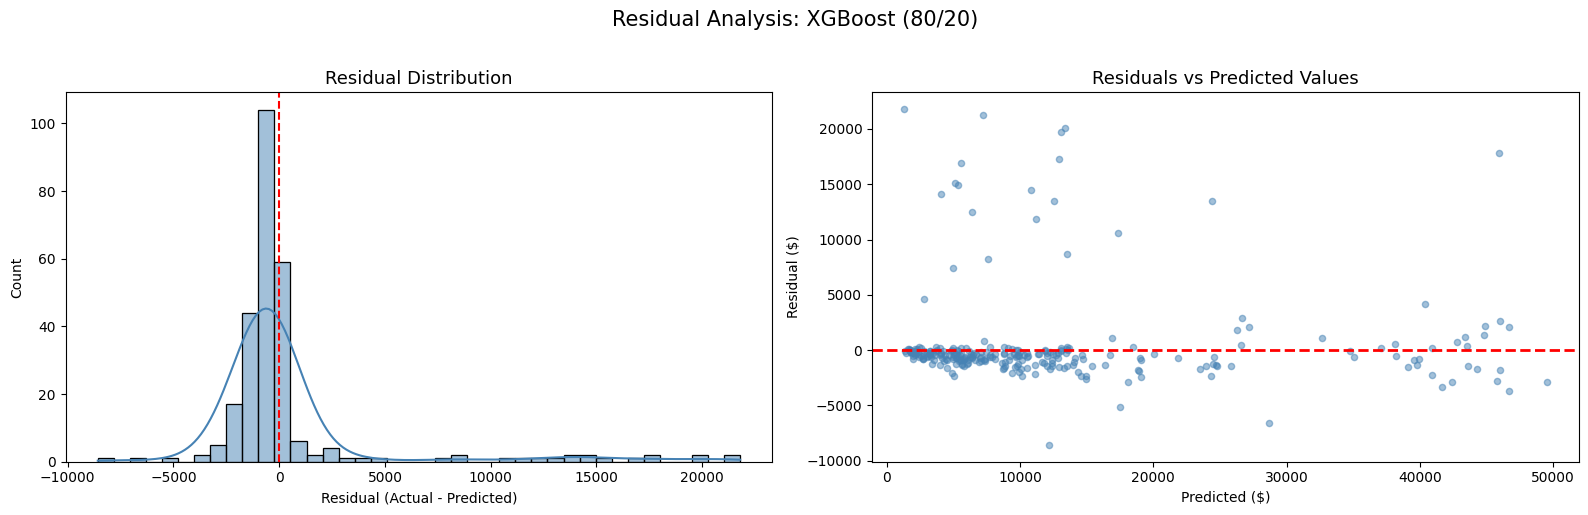

Mean residual:   $426.84
Std residual:    $4279.47


In [22]:
best_split = max(best_results, key=lambda s: max(m['test_r2'] for m in best_results[s].values()))
best_mn = max(best_results[best_split], key=lambda m: best_results[best_split][m]['test_r2'])
best_model_info = best_results[best_split][best_mn]

X_tr, X_te, _, _ = splits[best_split]
_, _, _, y_te_orig = splits_y_orig[best_split]

y_pred_log = best_model_info['model'].predict(X_te)
y_pred = np.expm1(y_pred_log)
residuals = y_te_orig - y_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(residuals, kde=True, bins=40, color='steelblue', ax=axes[0])
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution', fontsize=13)
axes[0].set_xlabel('Residual (Actual - Predicted)')

axes[1].scatter(y_pred, residuals, alpha=0.5, s=20, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs Predicted Values', fontsize=13)
axes[1].set_xlabel('Predicted ($)')
axes[1].set_ylabel('Residual ($)')

plt.suptitle(f'Residual Analysis: {best_mn} ({best_split})', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean residual:   ${residuals.mean():.2f}")
print(f"Std residual:    ${residuals.std():.2f}")


## 9.3 Feature Importance


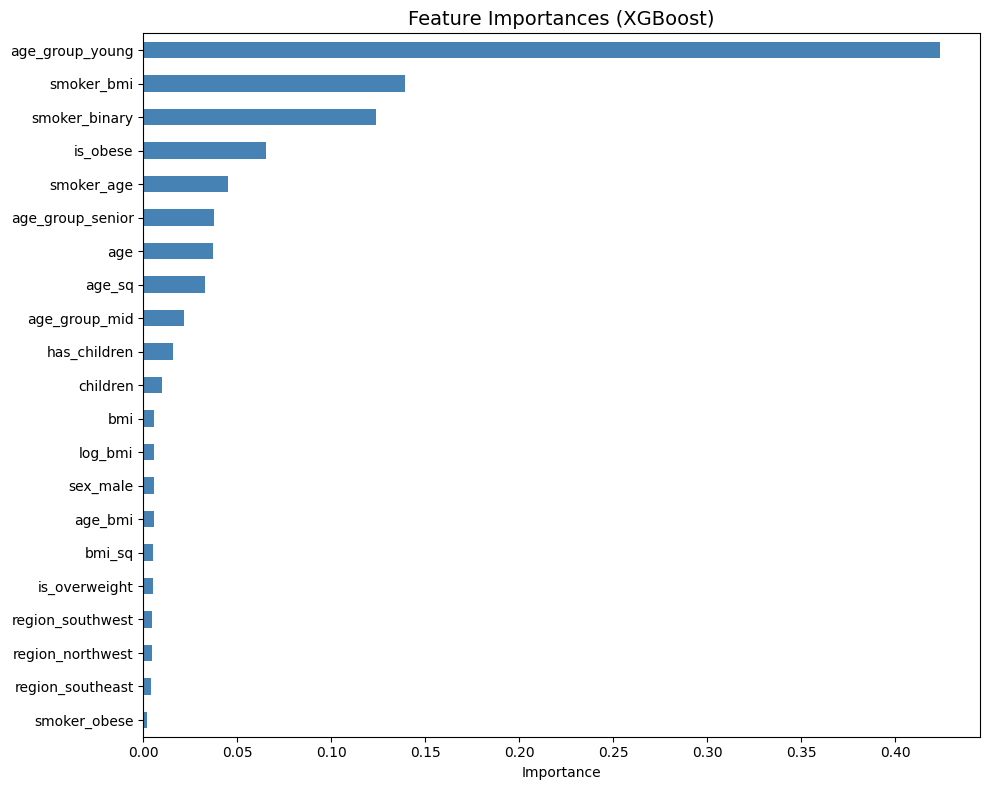


All features ranked by importance:
age_group_young     0.423758
smoker_bmi          0.139386
smoker_binary       0.123550
is_obese            0.065161
smoker_age          0.044981
age_group_senior    0.037745
age                 0.036917
age_sq              0.032556
age_group_mid       0.021626
has_children        0.015931
children            0.009762
bmi                 0.005881
log_bmi             0.005834
sex_male            0.005761
age_bmi             0.005536
bmi_sq              0.005289
is_overweight       0.004940
region_southwest    0.004849
region_northwest    0.004502
region_southeast    0.004270
smoker_obese        0.001763


In [23]:
if hasattr(best_model_info['model'], 'feature_importances_'):
    importances = best_model_info['model'].feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

    plt.figure(figsize=(10, 8))
    feat_imp.plot(kind='barh', color='steelblue')
    plt.title(f'Feature Importances ({best_mn})', fontsize=14)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print("\nAll features ranked by importance:")
    print(feat_imp.sort_values(ascending=False).to_string())
else:
    print(f"{best_mn} does not provide feature importances.")


## 9.4 Data Sparsity & Prediction Stability Analysis

Understanding how data density affects model reliability across the feature space.


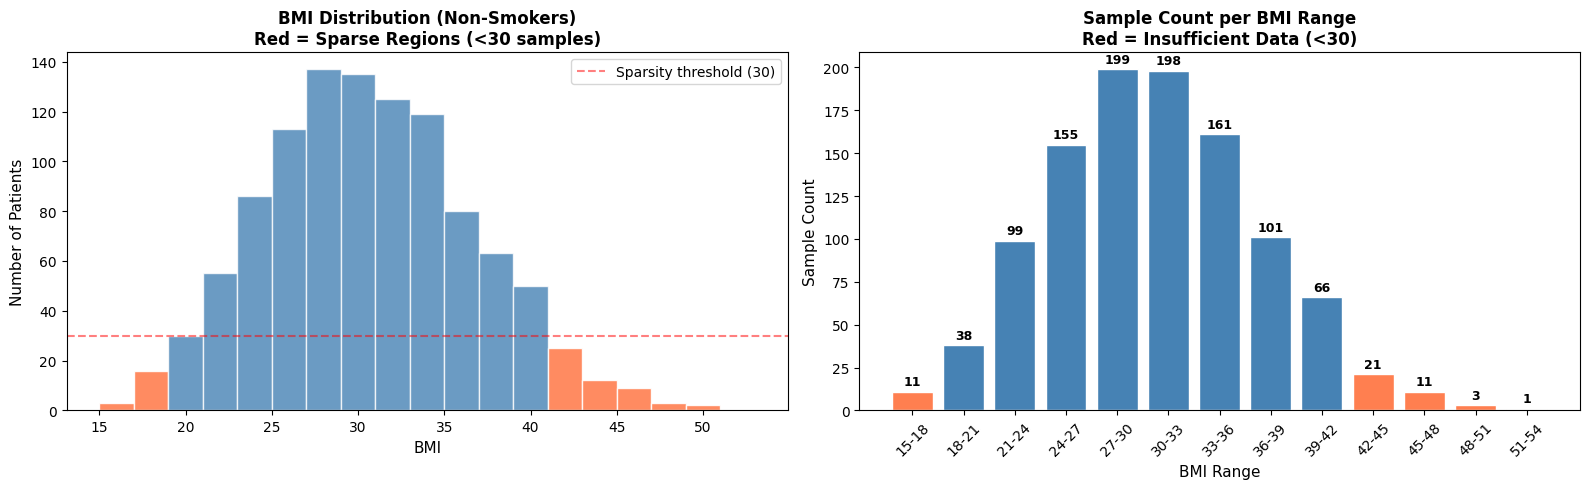

Sparse BMI regions (<30 samples) may cause prediction instability.
BMI 15-18: only 11 non-smoker samples
BMI 24-27: 155 samples (well-covered)


In [24]:
# Data Sparsity Analysis — Where does the model lack training data?
ns = data[data['smoker'] == 'no'] if 'smoker' in data.columns else data

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# BMI distribution (non-smokers)
bins_bmi = np.arange(15, 55, 2)
counts, edges, patches = axes[0].hist(ns['bmi'], bins=bins_bmi, color='steelblue', edgecolor='white', alpha=0.8)
for patch, count in zip(patches, counts):
    if count < 30:
        patch.set_facecolor('coral')
        patch.set_alpha(0.9)
axes[0].set_xlabel('BMI', fontsize=11)
axes[0].set_ylabel('Number of Patients', fontsize=11)
axes[0].set_title('BMI Distribution (Non-Smokers)\nRed = Sparse Regions (<30 samples)', fontsize=12, fontweight='bold')
axes[0].axhline(y=30, color='red', linestyle='--', alpha=0.5, label='Sparsity threshold (30)')
axes[0].legend()

# Sample count per BMI range (bar chart)
bin_edges = np.arange(15, 55, 3)
bin_labels = [f'{int(bin_edges[i])}-{int(bin_edges[i+1])}' for i in range(len(bin_edges)-1)]
bin_counts = []
for i in range(len(bin_edges)-1):
    c = len(ns[(ns['bmi'] >= bin_edges[i]) & (ns['bmi'] < bin_edges[i+1])])
    bin_counts.append(c)
colors4 = ['coral' if c < 30 else 'steelblue' for c in bin_counts]
bars = axes[1].bar(bin_labels, bin_counts, color=colors4, edgecolor='white')
axes[1].set_xlabel('BMI Range', fontsize=11)
axes[1].set_ylabel('Sample Count', fontsize=11)
axes[1].set_title('Sample Count per BMI Range\nRed = Insufficient Data (<30)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for bar, count in zip(bars, bin_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2, str(count),
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("Sparse BMI regions (<30 samples) may cause prediction instability.")
print(f"BMI 15-18: only {bin_counts[0]} non-smoker samples")
print(f"BMI 24-27: {bin_counts[3]} samples (well-covered)")



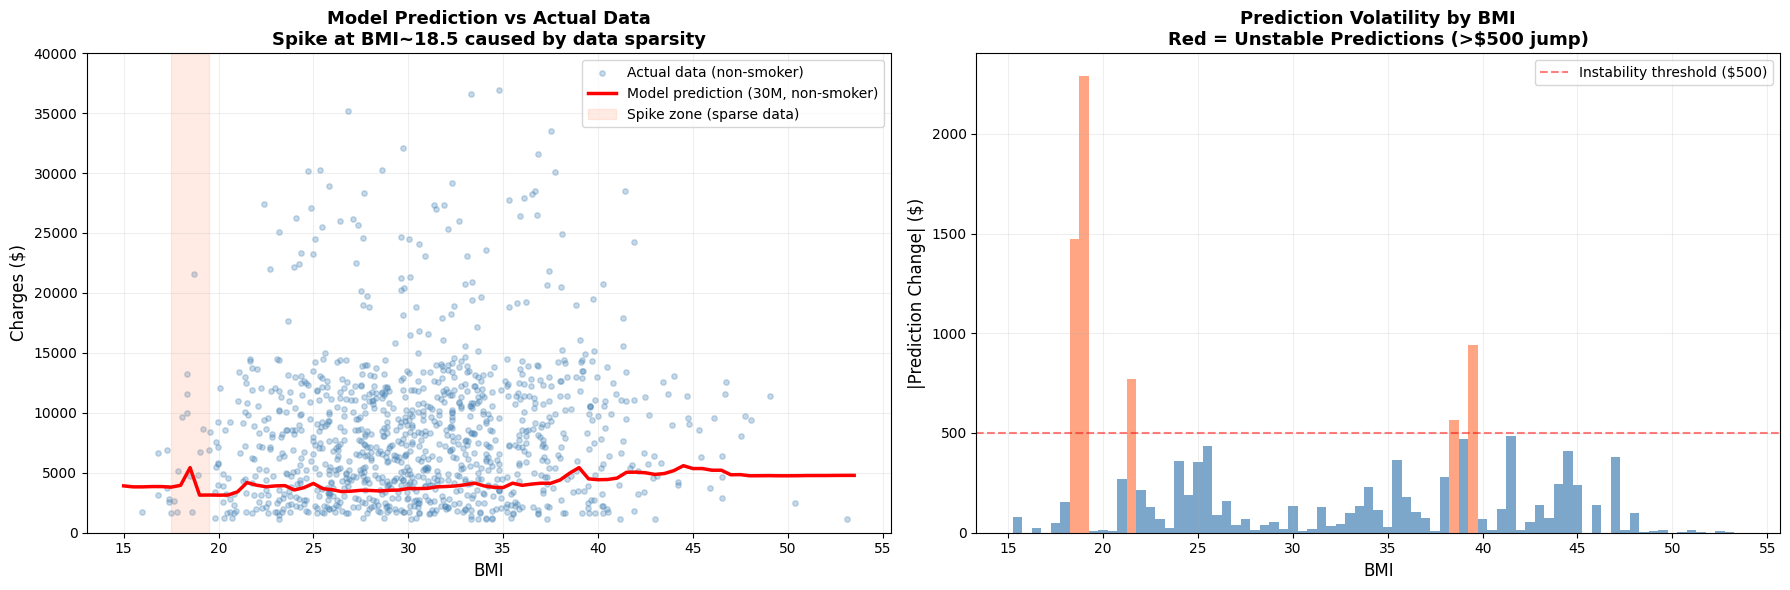

Key observation: Prediction instability correlates with data sparsity.
Where data is abundant (BMI 22-38), predictions are smooth and stable.
Where data is sparse (BMI <20, BMI >42), predictions become volatile.


In [25]:
# Prediction Curve vs Actual Data — Visualizing model behavior
# Use the best model to predict across the full BMI range

best_split = max(best_results, key=lambda s: max(m['test_r2'] for m in best_results[s].values()))
best_mn = max(best_results[best_split], key=lambda m: best_results[best_split][m]['test_r2'])
best_model = best_results[best_split][best_mn]['model']

# Create prediction sweep across BMI for a fixed profile (30M, non-smoker)
bmi_sweep = np.arange(15, 54, 0.5)
preds_sweep = []
for b in bmi_sweep:
    # Build a single-row feature vector matching the training features
    row = X.iloc[[0]].copy()
    row.iloc[0] = 0  # zero out all features
    row['age'] = 30
    row['bmi'] = b
    row['children'] = 0
    row['smoker_binary'] = 0
    row['smoker_bmi'] = 0
    row['smoker_age'] = 0
    row['age_sq'] = 900
    row['bmi_sq'] = b ** 2
    row['age_bmi'] = 30 * b
    row['is_obese'] = int(b >= 30)
    row['is_overweight'] = int(b >= 25)
    row['smoker_obese'] = 0
    row['age_group_young'] = 0
    row['age_group_mid'] = 1
    row['age_group_senior'] = 0
    row['has_children'] = 0
    row['log_bmi'] = np.log1p(b)
    row['sex_male'] = 1
    # region columns stay 0 (default = northeast)
    pred_log = best_model.predict(row)[0]
    preds_sweep.append(max(np.expm1(pred_log), 0))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Prediction curve with actual data
ns_data = data[data['smoker'] == 'no'] if 'smoker' in data.columns else data
axes[0].scatter(ns_data['bmi'], ns_data['charges'], alpha=0.3, s=15, color='steelblue', label='Actual data (non-smoker)')
axes[0].plot(bmi_sweep, preds_sweep, color='red', linewidth=2.5, label='Model prediction (30M, non-smoker)', zorder=5)
axes[0].axvspan(17.5, 19.5, alpha=0.15, color='coral', label='Spike zone (sparse data)')
axes[0].set_xlabel('BMI', fontsize=12)
axes[0].set_ylabel('Charges ($)', fontsize=12)
axes[0].set_title('Model Prediction vs Actual Data\nSpike at BMI~18.5 caused by data sparsity', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 40000)
axes[0].grid(alpha=0.2)

# Right: Prediction volatility
pred_arr = np.array(preds_sweep)
rolling_diff = np.abs(np.diff(pred_arr))
bar_colors = ['coral' if d > 500 else 'steelblue' for d in rolling_diff]
axes[1].bar(bmi_sweep[1:], rolling_diff, width=0.5, color=bar_colors, alpha=0.7)
axes[1].set_xlabel('BMI', fontsize=12)
axes[1].set_ylabel('|Prediction Change| ($)', fontsize=12)
axes[1].set_title('Prediction Volatility by BMI\nRed = Unstable Predictions (>$500 jump)', fontsize=13, fontweight='bold')
axes[1].axhline(y=500, color='red', linestyle='--', alpha=0.5, label='Instability threshold ($500)')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Key observation: Prediction instability correlates with data sparsity.")
print("Where data is abundant (BMI 22-38), predictions are smooth and stable.")
print("Where data is sparse (BMI <20, BMI >42), predictions become volatile.")



# 10. Save Best Model


In [26]:
best_split = max(best_results, key=lambda s: max(m['test_r2'] for m in best_results[s].values()))
best_mn = max(best_results[best_split], key=lambda m: best_results[best_split][m]['test_r2'])
best_model = best_results[best_split][best_mn]['model']
best_r2 = best_results[best_split][best_mn]['test_r2']

model_path = 'best_model_classic.pkl'
joblib.dump(best_model, model_path)
print(f"Best model saved: {best_mn}")
print(f"  Split:    {best_split}")
print(f"  Test R2:  {best_r2:.4f}")
print(f"  Test MAE: ${best_results[best_split][best_mn]['test_mae']:.2f}")
print(f"  Test RMSE:${best_results[best_split][best_mn]['test_rmse']:.2f}")
print(f"  Params:   {best_results[best_split][best_mn]['params']}")
print(f"  Saved to: {model_path}")


Best model saved: XGBoost
  Split:    80/20
  Test R2:  0.8813
  Test MAE: $1917.91
  Test RMSE:$18427711.68
  Params:   {'n_estimators': 800, 'learning_rate': 0.01, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 2.0, 'random_state': 42}
  Saved to: best_model_classic.pkl
